In [1]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/Cleaned/Case 2 Dataset.csv")


In [2]:
# VADER base
vader = SentimentIntensityAnalyzer()

# adaptasi dari beberapa lexicon NLP Indonesia
indo_lexicon = {
    # Positif
    'bagus': 2.0, 'baik': 1.5, 'hebat': 2.5, 'mantap': 2.0, 'keren': 2.0,
    'setuju': 1.5, 'dukung': 1.5, 'sukses': 2.0, 'berhasil': 2.0, 'manfaat': 1.5,
    'bermanfaat': 2.0, 'sejahtera': 2.0, 'meningkat': 1.0, 'berkembang': 1.0,
    'inovatif': 1.5, 'kreatif': 1.5, 'optimal': 1.5, 'efektif': 1.5,
    'transparan': 1.5, 'merata': 1.5, 'tepat': 1.0, 'lancar': 1.0,
    'senang': 2.0, 'bangga': 2.0, 'harap': 1.0, 'semangat': 1.5,

    # Negatif
    'buruk': -2.0, 'jelek': -2.0, 'gagal': -2.5, 'kacau': -2.5, 'bohong': -2.5,
    'korupsi': -3.0, 'manipulasi': -2.5, 'pencitraan': -2.0, 'sia': -1.5,
    'mubazir': -2.0, 'buang': -1.5, 'curang': -2.5, 'nepotisme': -2.5,
    'lambat': -1.5, 'terlambat': -1.5, 'tidak': -1.0, 'belum': -0.5,
    'mahal': -1.5, 'boros': -2.0, 'sia-sia': -2.0, 'percuma': -2.0,
    'kritik': -1.0, 'tolak': -2.0, 'protes': -1.5, 'kecewa': -2.5,
    'khawatir': -1.5, 'takut': -1.5, 'rugi': -2.0, 'susah': -1.5,

    # Netral/konteks
    'buzzer': -1.5, 'propaganda': -2.0, 'politis': -1.0,
}

# Update lexicon VADER dengan kata Indonesia
vader.lexicon.update(indo_lexicon)

def get_sentiment_vader(text):
    if pd.isna(text) or text.strip() == '':
        return 'netral', 0.0
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.02:
        return 'positif', compound
    elif compound <= -0.02:
        return 'negatif', compound
    else:
        return 'netral', compound

# Apply
df[['sentiment_vader', 'sentiment_score']] = df['clean_text'].apply(
    lambda x: pd.Series(get_sentiment_vader(x))
)

print("Distribusi Sentiment (VADER):")
print(df['sentiment_vader'].value_counts())
print(df['sentiment_vader'].value_counts(normalize=True).mul(100).round(1))

Distribusi Sentiment (VADER):
sentiment_vader
netral     9693
positif    3558
negatif    1749
Name: count, dtype: int64
sentiment_vader
netral     64.6
positif    23.7
negatif    11.7
Name: proportion, dtype: float64


In [3]:
# Keyword per frame — bisa lo tambahin sendiri sesuai temuan EDA
frame_keywords = {
    'ekonomi': [
        'umkm', 'katering', 'usaha', 'bisnis', 'ekonomi', 'pendapatan',
        'lapangan', 'kerja', 'supplier', 'bahan', 'pangan', 'harga',
        'pasar', 'petani', 'nelayan', 'subsidi', 'biaya', 'untung',
        'modal', 'omzet', 'produksi', 'komoditas', 'penjual', 'warung'
    ],
    'anggaran_fiskal': [
        'anggaran', 'dana', 'apbn', 'uang', 'trilun', 'miliar', 'rupiah',
        'fiskal', 'keuangan', 'sri mulyani', 'pajak', 'defisit', 'utang',
        'hutang', 'alokasi', 'pemotongan', 'efisiensi', 'potong', 'gaji',
        'korupsi', 'kkn', 'kroni', 'nepotisme', 'proyek'
    ],
    'gizi_kesehatan': [
        'gizi', 'sehat', 'nutrisi', 'vitamin', 'protein', 'stunting',
        'tumbuh', 'kembang', 'anak', 'siswa', 'pelajar', 'belajar',
        'konsentrasi', 'imun', 'kalori', 'menu', 'sayur', 'buah',
        'sakit', 'keracunan', 'mual', 'diare', 'basi', 'higienis'
    ],
    'keamanan_pangan': [
        'racun', 'beracun', 'keracunan', 'basi', 'busuk', 'kotor',
        'higienis', 'sanitasi', 'berbahaya', 'mati', 'sakit', 'rumah sakit',
        'oplos', 'oplosan', 'kimia', 'bahaya', 'percobaan', 'bunuh',
        'korban', 'tewas', 'meninggal'
    ],
    'kebijakan_implementasi': [
        'distribusi', 'implementasi', 'pelaksanaan', 'penyaluran',
        'target', 'sasaran', 'infrastruktur', 'koordinasi', 'dinas',
        'kemenag', 'kemendikbud', 'sekolah', 'pesantren', 'regulasi',
        'aturan', 'prosedur', 'mekanisme', 'pengadaan', 'tender',
        'merata', 'belum', 'dapur', 'unit', 'jadwal', 'terlambat',
        'evaluasi', 'monitoring', 'pengawasan'
    ],
    'political_skeptis': [
        'pencitraan', 'politik', 'politis', 'pilkada', 'pemilu', 'partai',
        'kampanye', 'janji', 'manipulasi', 'bohong', 'rezim', 'jokowi',
        'prabowo', 'presiden', 'perintah', 'gerombolan', 'antek',
        'elite', 'oligarki', 'kepentingan', 'populis', 'gemoy',
        'keluarga', 'kroni', 'kekuasaan', 'bencana'
    ],
    'dukungan_umum': [
        'dukung', 'dukungan', 'lanjutkan', 'terus', 'semangat', 'bagus',
        'keren', 'mantap', 'hebat', 'berhasil', 'sukses', 'bangga',
        'terima kasih', 'apresiasi', 'salut', 'Indonesia maju',
        'emas', 'masa depan', 'generasi', 'bangsa', 'cinta'
    ],
    'buzzer_hype': [
        'buzzer', 'bot', 'massal', 'serentak', 'tagar', 'trending',
        'viral', 'endorse', 'berbayar', 'bayaran', 'koordinasi'
    ],
    'agama_budaya': [
        'halal', 'haram', 'pesantren', 'santri', 'ulama', 'kyai',
        'agama', 'islam', 'kristen', 'hindu', 'budaya', 'adat',
        'lokal', 'tradisional', 'kearifan', 'masjid', 'gereja'
    ],
    'sosial_pemerataan': [
        'miskin', 'dhuafa', 'pelosok', 'desa', 'terpencil', 'merata',
        'adil', 'keadilan', 'kesenjangan', 'marginal', 'disabilitas',
        'yatim', 'panti', 'sulawesi', 'papua', 'daerah', 'wilayah'
    ]
}

def detect_frame(text):
    if pd.isna(text) or text.strip() == '':
        return 'tidak_terklasifikasi'

    text_lower = text.lower()
    frame_scores = {}

    for frame, keywords in frame_keywords.items():
        score = sum(1 for kw in keywords if kw in text_lower)
        if score > 0:
            frame_scores[frame] = score

    if not frame_scores:
        return 'tidak_terklasifikasi'

    # Ambil frame dengan score tertinggi
    return max(frame_scores, key=frame_scores.get)

def detect_all_frames(text):
    """Versi yang return SEMUA frame yang relevan (bukan cuma 1)"""
    if pd.isna(text) or text.strip() == '':
        return []
    text_lower = text.lower()
    return [
        frame for frame, keywords in frame_keywords.items()
        if any(kw in text_lower for kw in keywords)
    ]

df['frame_utama'] = df['clean_text'].apply(detect_frame)
df['all_frames']  = df['clean_text'].apply(detect_all_frames)

print("Distribusi Frame:")
print(df['frame_utama'].value_counts())

Distribusi Frame:
frame_utama
tidak_terklasifikasi      4288
gizi_kesehatan            3347
ekonomi                   1641
anggaran_fiskal           1624
dukungan_umum             1120
political_skeptis          921
kebijakan_implementasi     911
keamanan_pangan            838
sosial_pemerataan          172
buzzer_hype                100
agama_budaya                38
Name: count, dtype: int64


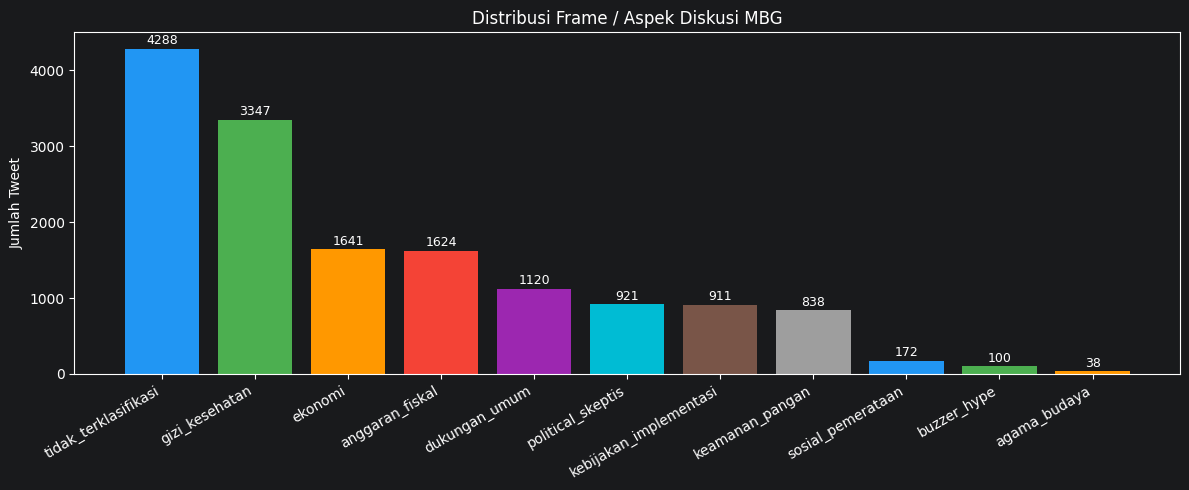

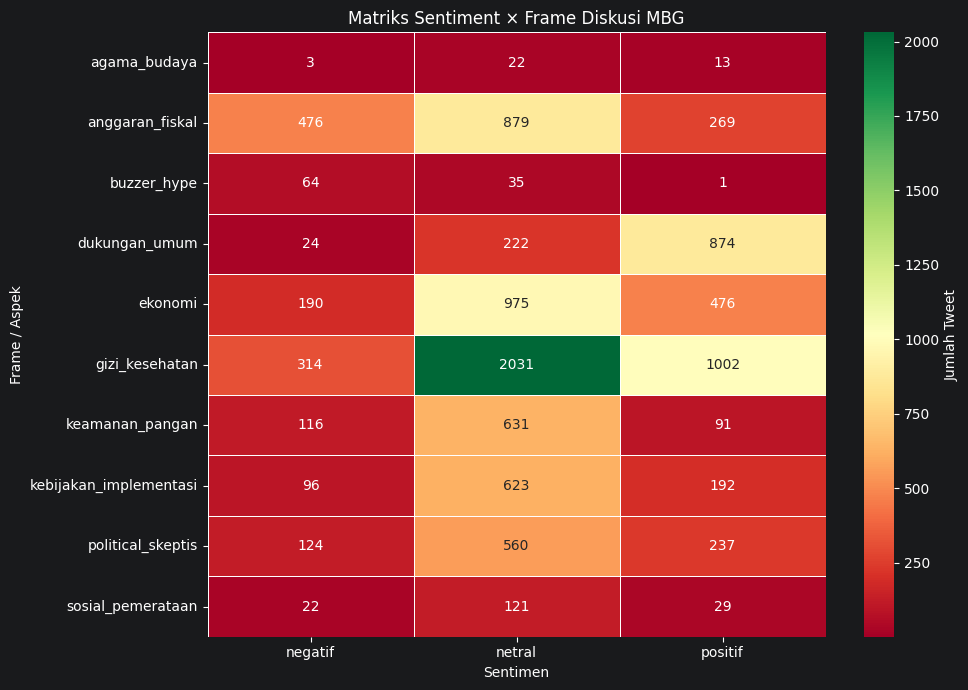

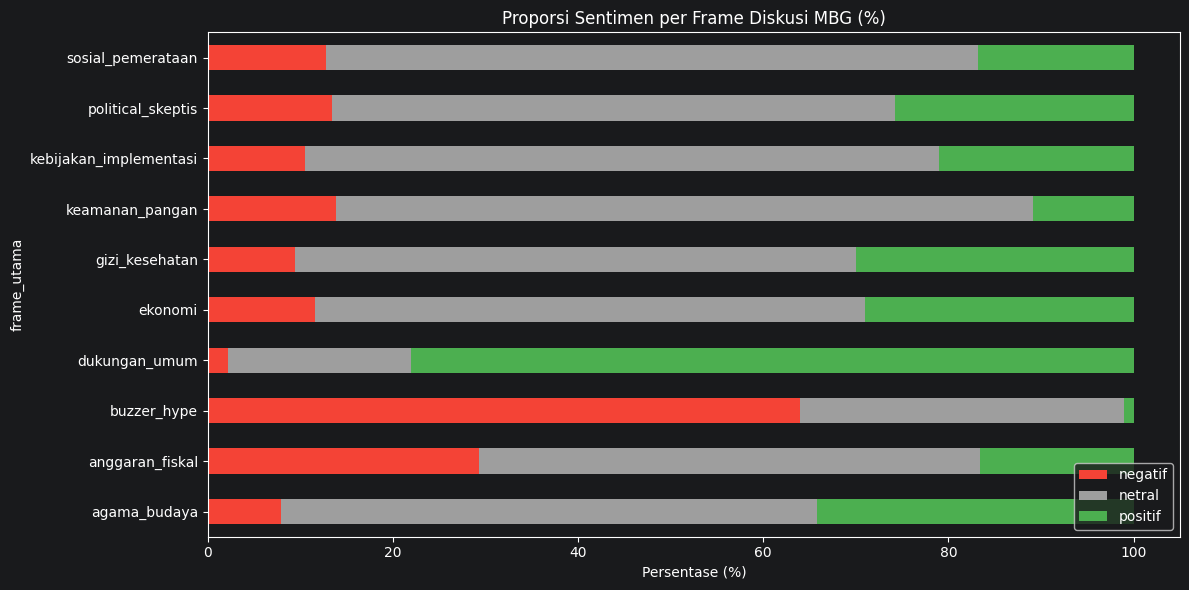


=== SAMPLE TWEET PER FRAME × SENTIMENT ===

[KEBIJAKAN_IMPLEMENTASI | POSITIF]
  KILAS BALIK: 1 Tahun Kemenag Kawal Asta Cita Presiden!

Dari memastikan MBG &amp; CKG utk jutaan siswa/santri, perkuat pendidikan, hingga sinergi kepe...

[KEBIJAKAN_IMPLEMENTASI | NEGATIF]
  MBG stop, evaluasi....

[GIZI_KESEHATAN | POSITIF]
  Melalui program MBG, negara hadir memastikan setiap anak Indonesia mendapatkan asupan gizi yang layak untuk tumbuh sehat, cerdas, dan bersemangat bela...

[GIZI_KESEHATAN | NEGATIF]
  @txtdrimedia Emangnya kenapa klo platform digital tau, apa lu takut masyarakat menguliti kebodohan lu dan banyaknya kasus keracunan juga makanan gk me...

[EKONOMI | POSITIF]
  @narkosun lebih baik untuk anak kita (Indonesia), masih baanyak yang tidak punya dana untuk kuliah. atau dananya untuk MBG kan butuh dana ?
Kecuali ki...

[EKONOMI | NEGATIF]
  Pejabat tuli
Antivax makin masif
Keracunan MBG
Cacingan
Ibadah haji dikorupsi
Penghargaan pejabat tuli
BPJS naik, klaim sulit
Pengaliha

In [4]:
# 1. Bar chart distribusi frame
plt.figure(figsize=(12, 5))
frame_counts = df['frame_utama'].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4','#795548','#9E9E9E']
bars = plt.bar(frame_counts.index, frame_counts.values, color=colors[:len(frame_counts)])
plt.xticks(rotation=30, ha='right')
plt.title('Distribusi Frame / Aspek Diskusi MBG')
plt.ylabel('Jumlah Tweet')
for bar, val in zip(bars, frame_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 2. Heatmap Sentiment x Frame (ini yang paling menarik buat lomba)
pivot_sf = pd.crosstab(df['frame_utama'], df['sentiment_vader'])

# Buang baris tidak_terklasifikasi biar bersih
pivot_sf = pivot_sf.drop('tidak_terklasifikasi', errors='ignore')

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_sf,
    annot=True, fmt='d',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Jumlah Tweet'}
)
plt.title('Matriks Sentiment × Frame Diskusi MBG')
plt.xlabel('Sentimen')
plt.ylabel('Frame / Aspek')
plt.tight_layout()
plt.show()

# 3. Stacked bar — proporsi sentiment per frame
pivot_pct = pivot_sf.div(pivot_sf.sum(axis=1), axis=0) * 100

pivot_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    color={'positif': '#4CAF50', 'negatif': '#F44336', 'netral': '#9E9E9E'}
)
plt.title('Proporsi Sentimen per Frame Diskusi MBG (%)')
plt.xlabel('Persentase (%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 4. Sample tweet per kombinasi (buat manual check)
print("\n=== SAMPLE TWEET PER FRAME × SENTIMENT ===")
for frame in df['frame_utama'].unique():
    if frame == 'tidak_terklasifikasi':
        continue
    for sent in ['positif', 'negatif']:
        subset = df[(df['frame_utama'] == frame) & (df['sentiment_vader'] == sent)]
        if len(subset) > 0:
            sample = subset['full_text'].sample(1, random_state=42).values[0]
            print(f"\n[{frame.upper()} | {sent.upper()}]")
            print(f"  {sample[:150]}...")

In [5]:
# Lihat sample tweet yang tidak terklasifikasi
tidak_ter = df[df['frame_utama'] == 'tidak_terklasifikasi']['clean_text'].dropna()

# Frequent words di tweet yang tidak terklasifikasi
from collections import Counter
words_tidak = " ".join(tidak_ter).split()
top_words = Counter(words_tidak).most_common(40)

print("=== TOP 40 KATA di tweet TIDAK TERKLASIFIKASI ===")
for word, count in top_words:
    print(f"  {word}: {count}")

# Sample tweet mentahnya
print("\n=== 20 SAMPLE TWEET TIDAK TERKLASIFIKASI ===")
for t in df[df['frame_utama'] == 'tidak_terklasifikasi']['full_text'].sample(20, random_state=42):
    print(f"- {t[:120]}")
    print()

=== TOP 40 KATA di tweet TIDAK TERKLASIFIKASI ===
  lebih: 168
  lanjut: 141
  hari: 133
  memang: 133
  benar: 125
  enggak: 123
  makan: 121
  buat: 119
  kan: 119
  anggar: 118
  aku: 116
  kasih: 115
  kamu: 114
  kayak: 109
  negara: 106
  masalah: 105
  jalan: 104
  tuh: 103
  baik: 102
  indonesia: 101
  kok: 99
  cuma: 99
  begini: 97
  jangan: 93
  lihat: 92
  baru: 90
  soal: 87
  pakai: 84
  tahu: 84
  mana: 83
  dulu: 83
  kata: 83
  penting: 81
  jadi: 80
  solusi: 78
  didik: 77
  malah: 76
  rakyat: 71
  kali: 71
  coba: 70

=== 20 SAMPLE TWEET TIDAK TERKLASIFIKASI ===
- MBG yang gak cuman goodie bag 😋

- @FOOD_FESS Mau makan sisa bekel MBG kemarin kak

- @ardisatriawan ai ai ai ai ai ai
mbg mbg mbg mbg mbg
ongkir ongkir ongkir ongkir
barak barak barak barak barak

- fuck prakfislan anjing segala ada uas disaat gua udah tenang di rumah tante gua dan gua besok berkemungkinan mendapat mb

- @DCHELSFC1 @multibank_io MBG rocks

- @KangManto123 cb pelaksana MBG suruh nyontohi

In [6]:
import torch
print(torch.backends.mps.is_available())  # harus True
print(torch.backends.mps.is_built())      # harus True

In [10]:
from transformers import pipeline
import torch
from dotenv import load_dotenv
import os

load_dotenv()

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

sentiment_model = pipeline(
    "text-classification",
    model="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa",
    truncation=True,
    max_length=128,
    device=device,
    token = os.getenv("TOKEN")
)

# Test
test = "program makan bergizi gratis ini sangat membantu anak anak"
print(sentiment_model(test))

device: mps


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 29760.49it/s]


[{'label': 'Positive', 'score': 0.9996647834777832}]


In [11]:
from tqdm import tqdm

# Batch inference - MPS lebih suka batch daripada satu-satu
def run_indobert_sentiment(texts, batch_size=64):
    results = []

    # Ganti teks kosong/NaN dengan string placeholder
    clean_texts = [t if isinstance(t, str) and t.strip() != '' else 'tidak ada teks'
                   for t in texts]

    for i in tqdm(range(0, len(clean_texts), batch_size), desc="IndoBERT"):
        batch = clean_texts[i:i+batch_size]
        try:
            preds = sentiment_model(batch)
            results.extend(preds)
        except Exception as e:
            print(f"Error di batch {i}: {e}")
            # Fallback: isi netral kalau batch gagal
            results.extend([{'label': 'neutral', 'score': 0.0}] * len(batch))

    return results

# Run — estimasi ~5-10 menit di M2 Pro
preds = run_indobert_sentiment(df['clean_text'].tolist())

# Parse hasil
label_map = {'positive': 'positif', 'negative': 'negatif', 'neutral': 'netral'}

df['sentiment_bert']       = [label_map.get(p['label'].lower(), p['label'].lower()) for p in preds]
df['sentiment_bert_score'] = [p['score'] for p in preds]

# Cek hasil
print("Distribusi Sentiment (IndoBERT):")
print(df['sentiment_bert'].value_counts())
print(df['sentiment_bert'].value_counts(normalize=True).mul(100).round(1))

# Bandingkan dengan VADER
print("\nKomparasi VADER vs IndoBERT:")
print(pd.crosstab(df['sentiment_vader'], df['sentiment_bert']))

IndoBERT: 100%|██████████| 235/235 [02:31<00:00,  1.55it/s]

Distribusi Sentiment (IndoBERT):
sentiment_bert
negatif    5951
netral     5590
positif    3459
Name: count, dtype: int64
sentiment_bert
negatif    39.7
netral     37.3
positif    23.1
Name: proportion, dtype: float64

Komparasi VADER vs IndoBERT:
sentiment_bert   negatif  netral  positif
sentiment_vader                          
negatif             1235     440       74
netral              3855    4011     1827
positif              861    1139     1558


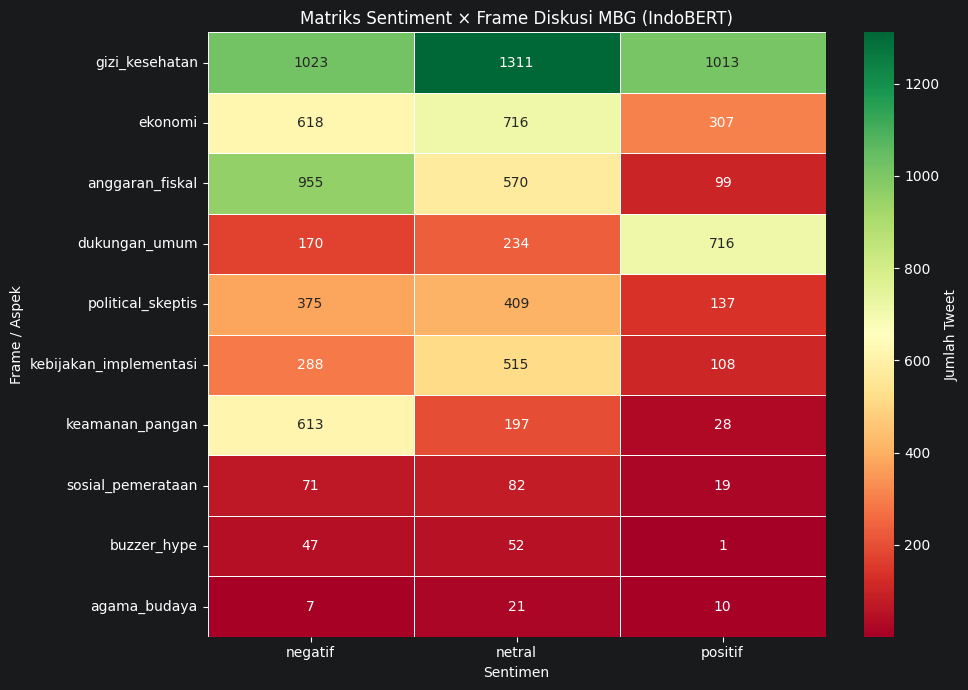

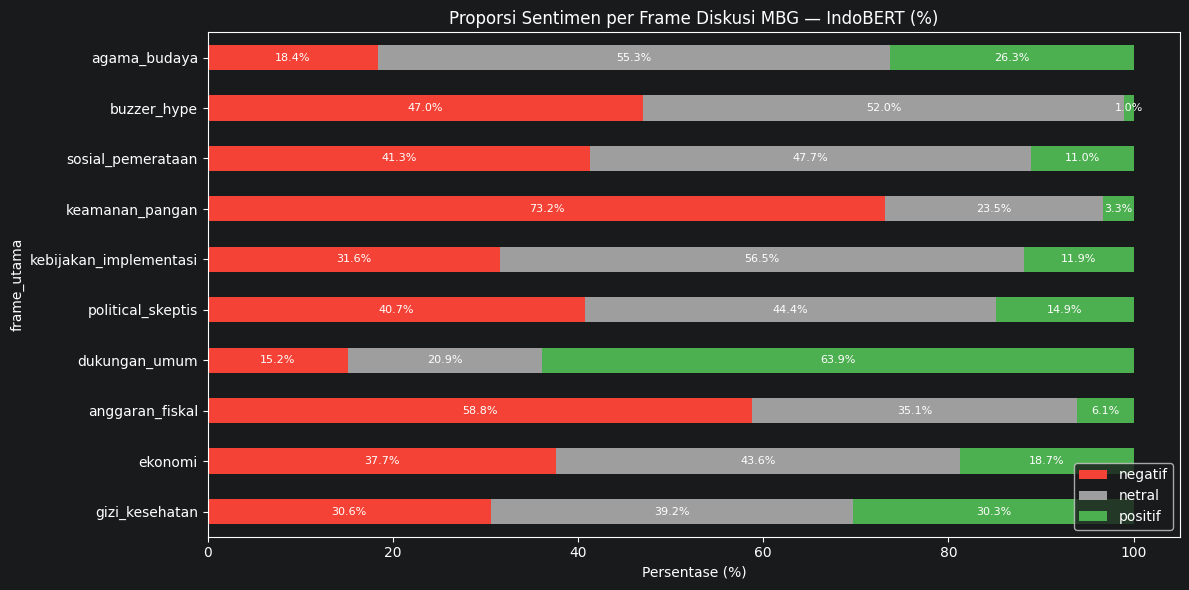

=== INSIGHT OTOMATIS (IndoBERT) ===
gizi_kesehatan                 | pos 30.3% | neg 30.6% | dominan → netral
ekonomi                        | pos 18.7% | neg 37.7% | dominan → netral
anggaran_fiskal                | pos 6.1% | neg 58.8% | dominan → negatif
dukungan_umum                  | pos 63.9% | neg 15.2% | dominan → positif
political_skeptis              | pos 14.9% | neg 40.7% | dominan → netral
kebijakan_implementasi         | pos 11.9% | neg 31.6% | dominan → netral
keamanan_pangan                | pos 3.3% | neg 73.2% | dominan → negatif
sosial_pemerataan              | pos 11.0% | neg 41.3% | dominan → netral
buzzer_hype                    | pos 1.0% | neg 47.0% | dominan → netral
agama_budaya                   | pos 26.3% | neg 18.4% | dominan → netral

Data tersimpan ke mbg_sentiment.csv


In [12]:
# Update insight dengan IndoBERT
pivot_bert = pd.crosstab(df['frame_utama'], df['sentiment_bert'])
pivot_bert = pivot_bert.drop('tidak_terklasifikasi', errors='ignore')
pivot_bert = pivot_bert.loc[pivot_bert.sum(axis=1).sort_values(ascending=False).index]

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_bert,
    annot=True, fmt='d',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Jumlah Tweet'}
)
plt.title('Matriks Sentiment × Frame Diskusi MBG (IndoBERT)')
plt.xlabel('Sentimen')
plt.ylabel('Frame / Aspek')
plt.tight_layout()
plt.show()

# Stacked bar
pivot_bert_pct = pivot_bert.div(pivot_bert.sum(axis=1), axis=0) * 100

ax = pivot_bert_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    color={'positif': '#4CAF50', 'negatif': '#F44336', 'netral': '#9E9E9E'}
)
plt.title('Proporsi Sentimen per Frame Diskusi MBG — IndoBERT (%)')
plt.xlabel('Persentase (%)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Insight otomatis
print("=== INSIGHT OTOMATIS (IndoBERT) ===")
for frame in pivot_bert.index:
    row = pivot_bert.loc[frame]
    total = row.sum()
    neg_pct = row.get('negatif', 0) / total * 100
    pos_pct = row.get('positif', 0) / total * 100
    dominant = row.idxmax()
    print(f"{frame:<30} | pos {pos_pct:.1f}% | neg {neg_pct:.1f}% | dominan → {dominant}")

# Simpan progress
df.to_csv("mbg_sentiment.csv", index=False)
print("\nData tersimpan ke mbg_sentiment.csv")

In [13]:
# Simpan dataframe utama dengan semua hasil analisis
df.to_csv("../Data/Analyzed/mbg_analyzed.csv", index=False)
print(f"Tersimpan: mbg_analyzed.csv ({len(df)} baris, {len(df.columns)} kolom)")
print(f"Kolom: {df.columns.tolist()}")

Tersimpan: mbg_analyzed.csv (15000 baris, 39 kolom)
Kolom: ['date', 'lang', 'source', 'user_id', 'hashtags', 'is_quote', 'mentions', 'tweet_id', 'username', 'verified', 'full_text', 'created_at', 'quoted_url', 'view_count', 'quote_count', 'quoted_text', 'reply_count', 'display_name', 'retweet_count', 'user_location', 'favorite_count', 'in_reply_to_url', 'quoted_tweet_id', 'quoted_username', 'user_created_at', 'user_description', 'in_reply_to_user_id', 'user_statuses_count', 'user_followers_count', 'user_following_count', 'in_reply_to_status_id', 'in_reply_to_screen_name', 'clean_text', 'sentiment_vader', 'sentiment_score', 'frame_utama', 'all_frames', 'sentiment_bert', 'sentiment_bert_score']
